In [10]:
import torchvision
import torch
import torchvision.transforms as transforms
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
from torch.utils.data import Dataset, DataLoader
from google.colab import drive
from tqdm import tqdm

In [11]:
#Kindly keep the dataset in the google drive and allow the permission to access it.
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# Copy Dataset to Local SSD
import shutil

if os.path.exists('/content/dataset'):
    print("Dataset already exists on local SSD, skipping copy.")
else:
    print("Copying dataset to local SSD...")
    shutil.copytree(
        '/content/drive/MyDrive/Colab Notebooks/dataset',
        '/content/dataset'
    )
    print("Done!")

train_dir = '/content/dataset/train'
val_dir   = '/content/dataset/val'

Dataset already exists on local SSD, skipping copy.


In [13]:
# transformations
from torchvision.transforms import transforms

dataset_mean = [0.485, 0.456, 0.406]
dataset_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=180),
    transforms.ToTensor(),
    #converting to 3 channels
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(mean = dataset_mean, std = dataset_std)
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(mean = dataset_mean, std = dataset_std)
])

In [14]:
# Dataset class

class LensingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.data = []
        self.labels = []
        self.transform = transform
        class_map = {'no': 0, 'sphere': 1, 'vort': 2}

        for class_name, label in class_map.items():
            class_path = os.path.join(root_dir, class_name)
            for fname in sorted(os.listdir(class_path)):
                self.data.append(os.path.join(class_path, fname))
                self.labels.append(label)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
      img = np.load(self.data[idx])
      img = img.squeeze(0)
      img = (img * 255).astype(np.uint8)
      img = np.ascontiguousarray(img)
      img = Image.fromarray(img).convert('L')

      if self.transform:
          img = self.transform(img)

      return img, self.labels[idx]

# DataLoaders
train_dataset = LensingDataset(train_dir, transform=train_transform)
val_dataset   = LensingDataset(val_dir,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)} images | Val: {len(val_dataset)} images")

Train: 30003 images | Val: 7500 images


In [15]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 3
NUM_EPOCHS  = 40
CLASS_NAMES = ['no', 'sphere', 'vort']

print(f"Training on: {DEVICE}")

Training on: cuda


In [16]:
convnext = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

convnext.classifier[2] = nn.Sequential(
    nn.Linear(convnext.classifier[2].in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.5),
    nn.Linear(256, NUM_CLASSES)
)

convnext  = convnext.to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(convnext.parameters(), lr=1e-5, weight_decay=1e-4)

print(convnext.classifier)

Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=3, bias=True)
  )
)


In [9]:
history      = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):

    convnext.train()
    train_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch:02d}/{NUM_EPOCHS} [Train]"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = convnext(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    train_loss /= total
    train_acc   = correct / total

    convnext.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch:02d}/{NUM_EPOCHS} [Val]  "):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs  = convnext(imgs)
            loss     = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)

    val_loss /= total
    val_acc   = correct / total

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}  |  Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  |  Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(convnext.state_dict(), "best_convnext_tiny.pt")
        print(f"  ✓ Best model saved  →  Val Acc: {best_val_acc:.4f}")

    print("-" * 70)

print(f"\nTraining complete. Best Val Accuracy: {best_val_acc:.4f}")

Epoch 01/40 [Val]  : 100%|██████████| 118/118 [00:38<00:00,  3.09it/s]


Epoch 01/40  |  Train Loss: 1.0565  Train Acc: 0.4017  |  Val Loss: 0.8983  Val Acc: 0.5793
  ✓ Best model saved  →  Val Acc: 0.5793
----------------------------------------------------------------------


Epoch 02/40 [Val]  : 100%|██████████| 118/118 [00:34<00:00,  3.38it/s]


Epoch 02/40  |  Train Loss: 0.6710  Train Acc: 0.7175  |  Val Loss: 0.5961  Val Acc: 0.7593
  ✓ Best model saved  →  Val Acc: 0.7593
----------------------------------------------------------------------


Epoch 03/40 [Val]  : 100%|██████████| 118/118 [00:34<00:00,  3.38it/s]


...

Epoch 21/40  |  Train Loss: 0.2111  Train Acc: 0.9238  |  Val Loss: 0.1957  Val Acc: 0.9317
  ✓ Best model saved  →  Val Acc: 0.9317
----------------------------------------------------------------------


Epoch 22/40 [Val]  : 100%|██████████| 118/118 [00:34<00:00,  3.46it/s]


Epoch 22/40  |  Train Loss: 0.1998  Train Acc: 0.9289  |  Val Loss: 0.2368  Val Acc: 0.9188
----------------------------------------------------------------------


Epoch 23/40 [Train]:  25%|██▍       | 116/469 [02:14<06:47,  1.16s/it]


KeyboardInterrupt: 

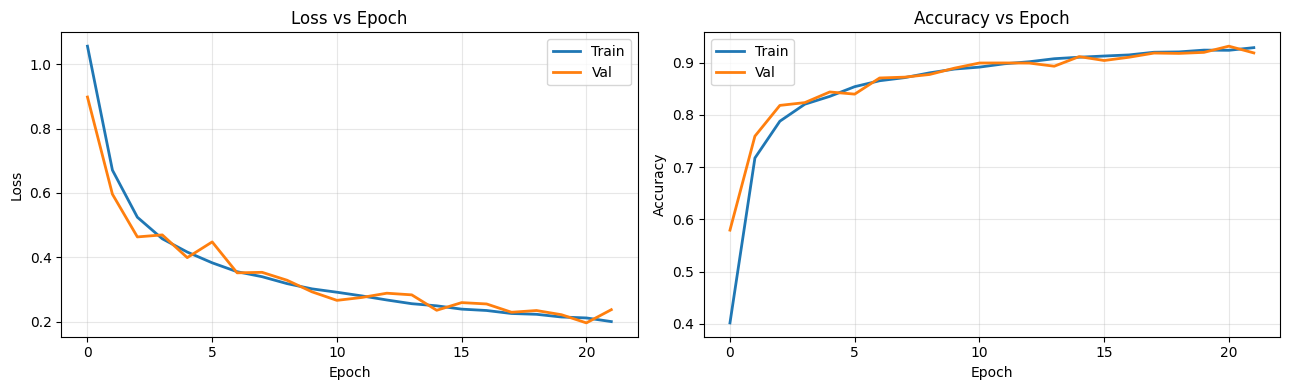

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val',   linewidth=2)
axes[0].set_title('Loss vs Epoch'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train', linewidth=2)
axes[1].plot(history['val_acc'],   label='Val',   linewidth=2)
axes[1].set_title('Accuracy vs Epoch'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("convnext_training_curves.png", dpi=150)
plt.show()

In [18]:
convnext.load_state_dict(torch.load("best_convnext_tiny.pt", map_location=DEVICE))
convnext.eval()

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc="Evaluating"):
        outputs = convnext(imgs.to(DEVICE))
        probs   = torch.softmax(outputs, dim=1).cpu().numpy()
        all_labels.extend(labels.numpy())
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_probs.extend(probs)

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

print(f"\nOverall Accuracy: {(all_preds == all_labels).mean():.4f}\n")
for i, name in enumerate(CLASS_NAMES):
    mask = all_labels == i
    print(f"  {name:>8s}  Accuracy: {(all_preds[mask] == all_labels[mask]).mean():.4f}")

Evaluating: 100%|██████████| 118/118 [00:34<00:00,  3.40it/s]


Overall Accuracy: 0.9317

        no  Accuracy: 0.9900
    sphere  Accuracy: 0.8828
      vort  Accuracy: 0.9224


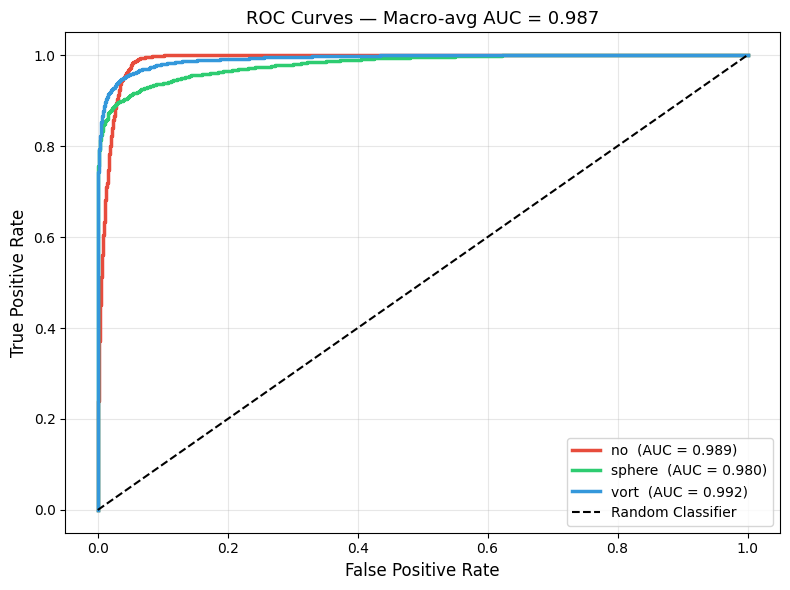

Macro-averaged AUC: 0.9869


In [19]:
colors    = ['#e74c3c', '#2ecc71', '#3498db']
fig, ax   = plt.subplots(figsize=(8, 6))
macro_auc = 0.0

for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve((all_labels == i).astype(int), all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    macro_auc  += roc_auc
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f"{name}  (AUC = {roc_auc:.3f})")

macro_auc /= NUM_CLASSES
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title(f'ROC Curves — Macro-avg AUC = {macro_auc:.3f}', fontsize=13)
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("convnext_roc_curves.png", dpi=150)
plt.show()
print(f"Macro-averaged AUC: {macro_auc:.4f}")

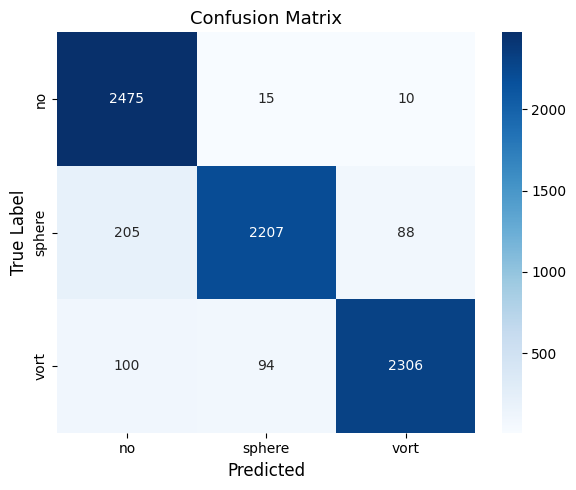

In [20]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=13)

plt.tight_layout()
plt.savefig("convnext_confusion_matrix.png", dpi=150)
plt.show()